In [1]:
import pandas as pd
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
from catomatic.BinaryCatalogue import BinaryBuilder
import pathlib

from protocols import utils, functions

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['font.size'] =7 
plt.rcParams['figure.figsize'] = (6.69, 5.02)

In [2]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = '/Users/fowler/Dropbox/files/cryptic/cryptic-release-three/cryptic-tables-v3.1.0/'

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 6

In [3]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value
    '''

    drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    phenotypes = prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version)
    
    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    #if not os.path.exists(catfile):
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cm, "cov": cov, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution
    '''

    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9]: #PWF: only one p-value for now, removed 0.95
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


In [4]:
if run_long_processes:

   # run grid search on crypticv3 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.1.0/",
      cryptic_tables_path+"DST_MEASUREMENTS_+.pkl",
      cryptic_tables_path+"GENOMES.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/cryptic-v1/grid_search",
      0.1,
      'v3.1.0',
      'v1.0',
      cores=n_cores #best to run with 1 core when first generating mutations and variants tables, as mem requirements are steep!!
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/grid_results_v1.csv')

else: 
   
   df = pd.read_csv('results/grid_search/grid_results_v1.csv')

df[:5]

,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2
0,0,BDQ,0.05,0.9,0.541284,0.990604,0.960216,0.495798,0.990974
1,1,BDQ,0.10,0.9,0.390244,0.994667,0.958041,0.268908,0.994877
2,2,BDQ,0.15,0.9,0.333333,0.995962,0.963276,0.210084,0.996097
3,3,BDQ,0.20,0.9,0.107143,0.999916,0.961343,0.050420,0.999919
4,4,BDQ,0.25,0.9,0.098361,0.999916,0.964484,0.050420,0.999919


In [5]:
# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "p_value"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "COVERAGE"],
    var_name="Metric",
    value_name="Value",
)

melted_df['value'] = 100* melted_df['Value']
melted_df.drop(columns=['Value'], inplace=True)
melted_df[:5]

,DRUG,BACKGROUND_RATE,p_value,Metric,value
0,BDQ,0.05,0.9,SENSITIVITY,54.128440
1,BDQ,0.10,0.9,SENSITIVITY,39.024390
2,BDQ,0.15,0.9,SENSITIVITY,33.333333
3,BDQ,0.20,0.9,SENSITIVITY,10.714286
4,BDQ,0.25,0.9,SENSITIVITY,9.836066


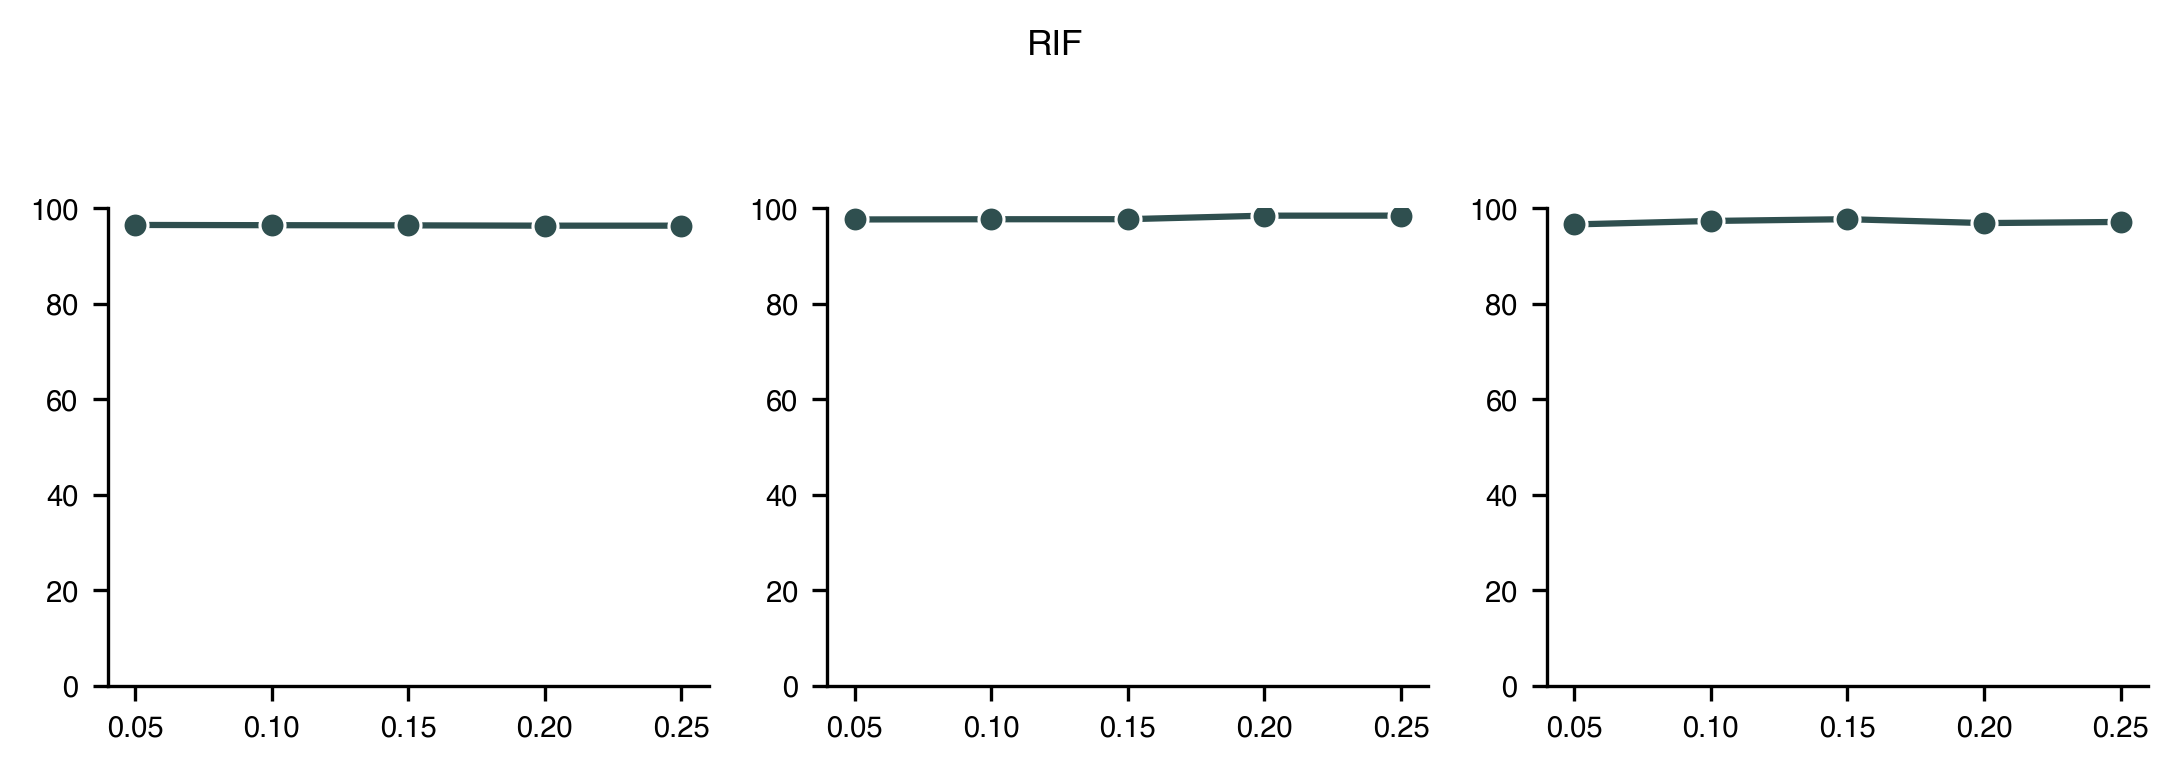

In [6]:

for drug in melted_df["DRUG"].unique():
    drug_data = melted_df[melted_df["DRUG"] == drug]
    g = sns.FacetGrid(drug_data, col="Metric", col_wrap=3, sharey=False, height=2.5)
    g.map_dataframe(
        sns.lineplot, x="BACKGROUND_RATE", y="value", hue="p_value", marker="o", palette=['darkslategrey']
    )
    # g.set_axis_labels("Background Rate", "")
    # g.add_legend(title="P Value")
    g.figure.suptitle(drug, y=1.05)
    g.tight_layout()
    g.set(ylim=(0, 100)) 

    for i in g.axes:
        i.set_xlabel("")
        i.set_title('')
        i.set_ylabel("")
        
    plt.savefig(f'figs/grid_search/{drug}.pdf', transparent=True)
    
    # show one exemplar drug 
    if drug == 'RIF':
        plt.show()
    plt.close()
    

array([<Axes: title={'center': 'Metric = SENSITIVITY'}, xlabel='BACKGROUND_RATE', ylabel='value'>,
       <Axes: title={'center': 'Metric = SPECIFICITY'}, xlabel='BACKGROUND_RATE'>,
       <Axes: title={'center': 'Metric = COVERAGE'}, xlabel='BACKGROUND_RATE'>],
      dtype=object)

In [18]:
#determine the best performing catalogue
opt_cats_v1 = utils.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

#pull out R, S, U counts from catalogue
cat_counts = pd.DataFrame([
    {
        "DRUG": opt_cats_v1['DRUG'][i],
        "R": cat["PREDICTION"].value_counts().get("R", 0),
        "S": cat["PREDICTION"].value_counts().get("S", 0),
        "U": cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(cat)
    }
    for i in opt_cats_v1.index
    for cat in [pd.read_csv(f"./catalogues/cryptic-v1/grid_search/{opt_cats_v1['DRUG'][i].lower()}/bg_{opt_cats_v1['BACKGROUND_RATE'][i]}_p_{opt_cats_v1['p_value'][i]}_FRS_0.1.csv")]
])

opt_cats_v1 = pd.merge(opt_cats_v1, cat_counts, on='DRUG')
opt_cats_v1['catalogue'] = 'catomatic_v1'
opt_cats_v1.drop(columns=['Unnamed: 0'], inplace=True)
opt_cats_v1.to_csv('results/grid_search/opt_cats_v1.csv',index=False)
opt_cats_v1

,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.25,0.9,0.963381,0.984365,0.971158,0.940540,0.984850,0.971232,41,25,347,413,catomatic_v1
1,INH,0.25,0.9,0.944380,0.988292,0.956512,0.915997,0.988895,0.959980,60,23,617,700,catomatic_v1
2,STM,0.20,0.9,0.954789,0.934732,0.911294,0.883635,0.940957,0.940073,89,12,509,610,catomatic_v1
3,EMB,0.25,0.9,0.952322,0.914556,0.906068,0.873186,0.922754,0.931741,17,53,1029,1099,catomatic_v1
4,PZA,0.05,0.9,0.884048,0.973402,0.974673,0.874152,0.974137,0.928979,417,1,157,575,catomatic_v1
5,LEV,0.20,0.9,0.922835,0.967359,0.880529,0.882075,0.971803,0.927731,14,15,317,346,catomatic_v1
6,MXF,0.25,0.9,0.943130,0.928090,0.868136,0.907238,0.938974,0.923619,11,18,383,412,catomatic_v1
7,AMI,0.05,0.9,0.848526,0.982960,0.922512,0.825884,0.984354,0.903654,14,8,387,409,catomatic_v1
8,CAP,0.05,0.9,0.844141,0.975157,0.920088,0.811816,0.977242,0.898635,43,4,232,279,catomatic_v1
9,ETH,0.05,0.9,0.913028,0.862800,0.914050,0.879388,0.876170,0.898164,295,4,358,657,catomatic_v1


In [54]:
rows = []

for idx,row in opt_cats_v1.iterrows():
    cat_path = pathlib.Path( "./catalogues/cryptic-v1/grid_search/") 
    cat =  cat_path / row.DRUG.lower() / f"bg_{row.BACKGROUND_RATE}_p_{row.p_value}_FRS_0.1.csv"
    if cat.is_file():
        df = pd.read_csv(cat)
        rows.append(df)

cat = pd.concat(rows)
cat.CATALOGUE_NAME = 'catomatic_v1'
cat.CATALOGUE_VERSION = '0.1'
cat = cat[['GENBANK_REFERENCE', 'CATALOGUE_NAME',
       'CATALOGUE_VERSION', 'CATALOGUE_GRAMMAR', 'PREDICTION_VALUES', 'DRUG',
       'MUTATION', 'PREDICTION', 'SOURCE', 'EVIDENCE', 'OTHER']]

cat.to_csv('catalogues/catomatic_v1.csv',index=False)
cat
    


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,catomatic_v1,0.1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.007196162046908316, ""confiden...",{}
1,NC00962.3,catomatic_v1,0.1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0494...",{}
2,NC00962.3,catomatic_v1,0.1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1446...",{}
3,NC00962.3,catomatic_v1,0.1,GARC1,RUS,RIF,rpoB@E563D,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.2129...",{}
4,NC00962.3,catomatic_v1,0.1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
...,...,...,...,...,...,...,...,...,...,...,...
265,NC00962.3,catomatic_v1,0.1,GARC1,RUS,CFZ,atpE@-*_indel,U,{},"{""default_rule"": ""True""}",{}
266,NC00962.3,catomatic_v1,0.1,GARC1,RUS,CFZ,atpE@*_indel,U,{},"{""default_rule"": ""True""}",{}
267,NC00962.3,catomatic_v1,0.1,GARC1,RUS,CFZ,atpE@-*?,U,{},"{""default_rule"": ""True""}",{}
268,NC00962.3,catomatic_v1,0.1,GARC1,RUS,CFZ,atpE@*?,U,{},"{""default_rule"": ""True""}",{}
